In [1]:
from llama_cpp import Llama
from langgraph.graph import StateGraph
from typing_extensions import TypedDict
from IPython.display import clear_output
from langchain_core.runnables import RunnableConfig
from typing import Annotated, Literal
import random
from IPython.display import Image, display


In [ ]:
# LLM定義
llm1 = Llama(
  model_path="..\..\models\Phi-3-mini-4k-instruct-q4.gguf",  # path to GGUF file
  n_gpu_layers=0, # The number of layers to offload to GPU, if you have GPU acceleration available. Set to 0 if no GPU acceleration is available on your system.
)
clear_output()

llm2 = Llama(
  model_path="..\..\models\Phi-3-mini-4k-instruct-q4.gguf",  # path to GGUF file
  n_gpu_layers=0, # The number of layers to offload to GPU, if you have GPU acceleration available. Set to 0 if no GPU acceleration is available on your system.
)
clear_output()

### グラフを作ってみる1

In [20]:
# reducer関数の宣言
def reducer(a: list, b: int | None) -> int:
    # bが渡されたときは、aに追加する
    if b is not None:
        return a + [b]
    return a

# # Stateを宣言
# class State(TypedDict):
#     # Annotatedでstateを更新するreducerを指定する
#     bar: Annotated[list[str], reducer]

# Stateを宣言
class State(TypedDict):
    value: str

# Nodeを宣言
def node1(state: State, config: RunnableConfig):
    return {"value": "hoge"}

def node2(state: State, config: RunnableConfig):
    return {"value": "fuga"}


# Stateを引数としてGraphを初期化
graph_builder = StateGraph(State)
graph_builder.add_node("node1", node1)
graph_builder.add_node("node2", node2)


# Nodeの関連をedgeに追加 
graph_builder.add_edge("node1", "node2")

# Graphの始点を宣言
graph_builder.set_entry_point("node1")

# Graphの終点を宣言
graph_builder.set_finish_point("node2")

# Graphをコンパイル
graph1 = graph_builder.compile()

# Graphの実行(引数にはStateの初期値を渡す)
# graph.invoke({"value": ""})
graph1.invoke({"value": ""}, debug=True)

[-1:checkpoint] State at the end of step -1:
{}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'value': ''}
[0:writes] Finished step 0 with writes to 1 channel:
- value -> ''
[0:checkpoint] State at the end of step 0:
{'value': ''}
[1:tasks] Starting 1 task for step 1:
- node1 -> {'value': ''}
[1:writes] Finished step 1 with writes to 1 channel:
- value -> 'hoge'
[1:checkpoint] State at the end of step 1:
{'value': 'hoge'}
[2:tasks] Starting 1 task for step 2:
- node2 -> {'value': 'hoge'}
[2:writes] Finished step 2 with writes to 1 channel:
- value -> 'fuga'
[2:checkpoint] State at the end of step 2:
{'value': 'fuga'}


{'value': 'fuga'}

### グラフを作ってみる2

In [21]:
# add_conditional_edgesに渡す関数
def routing(state: State, config: RunnableConfig) -> Literal["node1", "node2"]:
  # random_numが0なら次のpathは"node2"になり、1なら"node3"になる。
  random_num = random.randint(0, 1)
  if random_num == 0:
    return "node1"
  else:
    return "node2"
  
# Stateを引数としてGraphを初期化
graph_builder = StateGraph(State)

# nodeの追加
graph_builder.add_node("start_node", lambda state: {"value": state["value"]})
graph_builder.add_node("node1", node1)
graph_builder.add_node("node2", node2)
graph_builder.add_node("end_node", lambda state: {"value": state["value"]})


# edgeの追加
graph_builder.set_entry_point("start_node")
graph_builder.add_conditional_edges(
    "start_node",
    routing,
)
graph_builder.add_edge("node1", "end_node")
graph_builder.add_edge("node2", "end_node")
graph_builder.set_finish_point("end_node")

# Graphをコンパイル
graph2 = graph_builder.compile()

# Graphの実行(引数にはStateの初期値を渡す)
# graph.invoke({"value": ""})
graph2.invoke({"value": ""}, debug=True)

[-1:checkpoint] State at the end of step -1:
{}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'value': ''}
[0:writes] Finished step 0 with writes to 1 channel:
- value -> ''
[0:checkpoint] State at the end of step 0:
{'value': ''}
[1:tasks] Starting 1 task for step 1:
- start_node -> {'value': ''}
[1:writes] Finished step 1 with writes to 1 channel:
- value -> ''
[1:checkpoint] State at the end of step 1:
{'value': ''}
[2:tasks] Starting 1 task for step 2:
- node1 -> {'value': ''}
[2:writes] Finished step 2 with writes to 1 channel:
- value -> 'hoge'
[2:checkpoint] State at the end of step 2:
{'value': 'hoge'}
[3:tasks] Starting 1 task for step 3:
- end_node -> {'value': 'hoge'}
[3:writes] Finished step 3 with writes to 1 channel:
- value -> 'hoge'
[3:checkpoint] State at the end of step 3:
{'value': 'hoge'}


{'value': 'hoge'}

### 可視化してみる

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node1(node1)
	node2(node2)
	__end__([<p>__end__</p>]):::last
	__start__ --> node1;
	node1 --> node2;
	node2 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



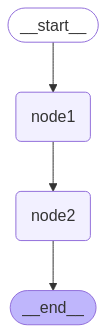

In [25]:
print(graph1.get_graph().draw_mermaid())
display(Image(graph1.get_graph().draw_mermaid_png()))

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	start_node(start_node)
	node1(node1)
	node2(node2)
	end_node(end_node)
	__end__([<p>__end__</p>]):::last
	__start__ --> start_node;
	node1 --> end_node;
	node2 --> end_node;
	start_node -.-> node1;
	start_node -.-> node2;
	end_node --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



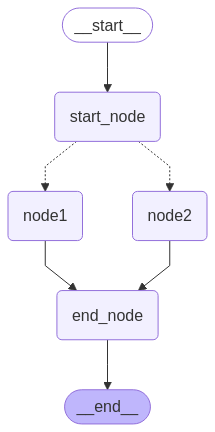

In [26]:
print(graph2.get_graph().draw_mermaid())
display(Image(graph2.get_graph().draw_mermaid_png()))

### グラフを作ってみる3

In [64]:
# reducer関数の宣言
def reducer(a: list[int], b: int | None) -> list[int]:
    # bが渡されたときは、aに追加する
    print("reducer", a, b)
    if b is not None:
        return a + [b]
    return a

def reducer_add(a: int, b: int | None) -> int:
    # bが渡されたときは、aに追加する
    if b is not None:
        return a + b
    return a


# Stateを宣言
class State(TypedDict):
    # Annotatedでstateを更新するreducerを指定する
    list_value: Annotated[list[int], reducer]
    int_value: Annotated[int, reducer_add]

# Nodeを宣言
def node1(state: State, config: RunnableConfig) -> State:
    print("node1_state:", state)
    return {
        "list_value": "node1", 
        "int_value": 5, 
    }

def node2(state: State, config: RunnableConfig) -> State:
    print("node2_state:", state)
    return {
        "list_value": "node2", 
        "int_value": 3, 
    }
 


# Stateを引数としてGraphを初期化
graph_builder = StateGraph(State)
graph_builder.add_node("node1", node1)
graph_builder.add_node("node2", node2)


# Nodeの関連をedgeに追加 
graph_builder.add_edge("node1", "node2")

# Graphの始点を宣言
graph_builder.set_entry_point("node1")

# Graphの終点を宣言
graph_builder.set_finish_point("node2")

# Graphをコンパイル
graph = graph_builder.compile()

# Graphの実行(引数にはStateの初期値を渡す)
# graph.invoke({"value": ""})
graph.invoke({
    "list_value": "start",
    "int_value": 52,
    }
)

reducer [] start
node1_state: {'list_value': ['start'], 'int_value': 52}
reducer ['start'] node1
node2_state: {'list_value': ['start', 'node1'], 'int_value': 57}
reducer ['start', 'node1'] node2


{'list_value': ['start', 'node1', 'node2'], 'int_value': 60}

### グラフを作ってみる4（LLMかませてみる）

In [9]:
# 区切りprefix
target = "<|assistant|>"

# chat_historyがわかるreducer関数の宣言
def chat_history_reducer(history: list[dict[str:str]], chat:dict[str:str] | None) -> list[dict[str:str]]:
    if chat is not None:
        return history + [chat]
    return history

# Stateを宣言
class State(TypedDict):
    name: str
    text: str
    history: Annotated[list[dict[str:str]], chat_history_reducer]

# Nodeを宣言
def node1(state: State, config: RunnableConfig) -> State:
    prompt= [
        {"role": "system", "content": "あなたは先生です。質問にこたえてください。"},
        {"role": "user", "content": state["text"]},
    ]
    output = llm1(
        f"<|user|>\n{prompt}<|end|>\n<|assistant|>",
        max_tokens=512,
        stop=["<|end|>"],
        echo=True
    )
    idx = output['choices'][0]['text'].find(target)
    text = output['choices'][0]['text'][idx+len(target):].replace("\n", " ")
    return {
        "name": "node1_teacher",
        "text": text,
        "history": {"node1_teacher": text},
    }

# Nodeを宣言
def node2(state: State, config: RunnableConfig) -> State:
    print(state["text"])
    prompt= [
        {"role": "system", "content": "小学生向けに内容を一言で要約してください。"},
        {"role": "user", "content": state["text"]},
    ]
    output = llm2(
        f"<|user|>\n{prompt}<|end|>\n<|assistant|>",
        max_tokens=1024,
        stop=["<|end|>"],
        echo=True
    )
    idx = output['choices'][0]['text'].find(target)
    text = output['choices'][0]['text'][idx+len(target):].replace("\n", " ")
    return {
        "name": "node2_student",
        "text": text,
        "history": {"node2_student": text},
    } 


# Stateを引数としてGraphを初期化
graph_builder = StateGraph(State)
graph_builder.add_node("node1", node1)
graph_builder.add_node("node2", node2)


# Nodeの関連をedgeに追加 
graph_builder.add_edge("node1", "node2")

# Graphの始点を宣言
graph_builder.set_entry_point("node1")

# Graphの終点を宣言
graph_builder.set_finish_point("node2")

# Graphをコンパイル
graph = graph_builder.compile()

# Graphの実行(引数にはStateの初期値を渡す)
# graph.invoke({"value": ""})
chat_history = graph.invoke(
    {
        "name": "start_me",
        "text": "日本の少子化問題について、300文字程度で、その原因をいくつか挙げてください。",
    },
    debug=True
)["history"]

[-1:checkpoint] State at the end of step -1:
{'history': []}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'name': 'start_me', 'text': '日本の少子化問題について、300文字程度で、その原因をいくつか挙げてください。'}
[0:writes] Finished step 0 with writes to 2 channels:
- name -> 'start_me'
- text -> '日本の少子化問題について、300文字程度で、その原因をいくつか挙げてください。'
[0:checkpoint] State at the end of step 0:
{'history': [],
 'name': 'start_me',
 'text': '日本の少子化問題について、300文字程度で、その原因をいくつか挙げてください。'}
[1:tasks] Starting 1 task for step 1:
- node1 -> {'history': [],
 'name': 'start_me',
 'text': '日本の少子化問題について、300文字程度で、その原因をいくつか挙げてください。'}


Llama.generate: 97 prefix-match hit, remaining 1 prompt tokens to eval
llama_perf_context_print:        load time =    3654.18 ms
llama_perf_context_print: prompt eval time =       0.00 ms /     1 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =   25968.42 ms /   294 runs   (   88.33 ms per token,    11.32 tokens per second)
llama_perf_context_print:       total time =   26133.90 ms /   295 tokens
Llama.generate: 64 prefix-match hit, remaining 280 prompt tokens to eval


[1:writes] Finished step 1 with writes to 3 channels:
- name -> 'node1_teacher'
- text -> (' '
 '日本の少子化問題は多くの複合因子によって引き起こされています。主な原因として挙げられます。まず、高齢化社会にあるとき、若年層が生まれる機会が少なくなっています。さらに、仕事と子育てのバランスが難しくなっており、多くの女性が働く環境が悪化しています。また、高額な医療費と教育費の増加により、子どもを持つコストが高まっています。最後に、生活様式の変化により、若者が婚姻や子育てを選択する意欲が低下しているという認識があります。これらの要因が相互作用し、少子化を引き起こしています。')
- history -> {'node1_teacher': ' '
                  '日本の少子化問題は多くの複合因子によって引き起こされています。主な原因として挙げられます。まず、高齢化社会にあるとき、若年層が生まれる機会が少なくなっています。さらに、仕事と子育てのバランスが難しくなっており、多くの女性が働く環境が悪化しています。また、高額な医療費と教育費の増加により、子どもを持つコストが高まっています。最後に、生活様式の変化により、若者が婚姻や子育てを選択する意欲が低下しているという認識があります。これらの要因が相互作用し、少子化を引き起こしています。'}
[1:checkpoint] State at the end of step 1:
{'history': [{'node1_teacher': ' '
                               '日本の少子化問題は多くの複合因子によって引き起こされています。主な原因として挙げられます。まず、高齢化社会にあるとき、若年層が生まれる機会が少なくなっています。さらに、仕事と子育てのバランスが難しくなっており、多くの女性が働く環境が悪化しています。また、高額な医療費と教育費の増加により、子どもを持つコストが高まっています。最後に、生活様式の変化により、若者が婚姻や子育てを選択する意欲が低下しているという認識があります。これらの要因が相互作用し、少子化を引き起こしています。'}],
 'name': 'node

llama_perf_context_print:        load time =   16034.47 ms
llama_perf_context_print: prompt eval time =    9559.44 ms /   280 tokens (   34.14 ms per token,    29.29 tokens per second)
llama_perf_context_print:        eval time =    7275.12 ms /    84 runs   (   86.61 ms per token,    11.55 tokens per second)
llama_perf_context_print:       total time =   16862.42 ms /   364 tokens


[2:writes] Finished step 2 with writes to 3 channels:
- name -> 'node2_student'
- text -> ' 日本の少子問題は、高齢化、労働と育児のバランス、医療や教育費の上昇、生活様式の変化など、多くの要因が絡み合っています。'
- history -> {'node2_student': ' '
                  '日本の少子問題は、高齢化、労働と育児のバランス、医療や教育費の上昇、生活様式の変化など、多くの要因が絡み合っています。'}
[2:checkpoint] State at the end of step 2:
{'history': [{'node1_teacher': ' '
                               '日本の少子化問題は多くの複合因子によって引き起こされています。主な原因として挙げられます。まず、高齢化社会にあるとき、若年層が生まれる機会が少なくなっています。さらに、仕事と子育てのバランスが難しくなっており、多くの女性が働く環境が悪化しています。また、高額な医療費と教育費の増加により、子どもを持つコストが高まっています。最後に、生活様式の変化により、若者が婚姻や子育てを選択する意欲が低下しているという認識があります。これらの要因が相互作用し、少子化を引き起こしています。'},
             {'node2_student': ' '
                               '日本の少子問題は、高齢化、労働と育児のバランス、医療や教育費の上昇、生活様式の変化など、多くの要因が絡み合っています。'}],
 'name': 'node2_student',
 'text': ' 日本の少子問題は、高齢化、労働と育児のバランス、医療や教育費の上昇、生活様式の変化など、多くの要因が絡み合っています。'}


In [13]:
from pprint import pprint 
pprint(chat_history)

[{'node1_teacher': ' '
                   '日本の少子化問題は多くの複合因子によって引き起こされています。主な原因として挙げられます。まず、高齢化社会にあるとき、若年層が生まれる機会が少なくなっています。さらに、仕事と子育てのバランスが難しくなっており、多くの女性が働く環境が悪化しています。また、高額な医療費と教育費の増加により、子どもを持つコストが高まっています。最後に、生活様式の変化により、若者が婚姻や子育てを選択する意欲が低下しているという認識があります。これらの要因が相互作用し、少子化を引き起こしています。'},
 {'node2_student': ' '
                   '日本の少子問題は、高齢化、労働と育児のバランス、医療や教育費の上昇、生活様式の変化など、多くの要因が絡み合っています。'}]


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node1(node1)
	node2(node2)
	__end__([<p>__end__</p>]):::last
	__start__ --> node1;
	node1 --> node2;
	node2 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



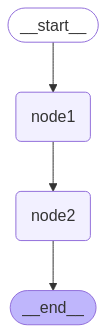

In [12]:
print(graph.get_graph().draw_mermaid())
display(Image(graph.get_graph().draw_mermaid_png()))